# Q_1: Housing Prices
Load clean q1_clean: https://raw.githubusercontent.com/DS3001/linearRegression/refs/heads/main/data/Q1_clean.csv 

The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighborhood `: The bourough of NYC. Note the space, or rename the variable.
- `Property Type`: The kind of dwelling
- `Room Type`: The kind of space being rented


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [18]:
url = "https://raw.githubusercontent.com/DS3001/linearRegression/refs/heads/main/data/Q1_clean.csv"

house_raw = pd.read_csv(url)
house_raw.head()

,Price,Review Scores Rating,Neighbourhood,Property Type,Room Type
0,549,96.0,Manhattan,Apartment,Private room
1,149,100.0,Brooklyn,Apartment,Entire home/apt
2,250,100.0,Manhattan,Apartment,Entire home/apt
3,90,94.0,Brooklyn,Apartment,Private room
4,270,90.0,Manhattan,Apartment,Entire home/apt


In [19]:
# we will need to adjust some variables to category variables
house_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 22153 entries, 0 to 22152
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Price                 22153 non-null  int64  
 1   Review Scores Rating  22153 non-null  float64
 2   Neighbourhood         22153 non-null  str    
 3   Property Type         22153 non-null  str    
 4   Room Type             22153 non-null  str    
dtypes: float64(1), int64(1), str(3)
memory usage: 865.5 KB


In [20]:
# there are unwanted characters in the column headers that we need to remove
house_raw.columns = house_raw.columns.str.strip()

In [21]:
# we need to make certain variables into categorical vars
cat_vars = ['Neighbourhood' , 'Property Type' , 'Room Type']
house_raw[cat_vars] = house_raw[cat_vars].astype("category")
house_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 22153 entries, 0 to 22152
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   Price                 22153 non-null  int64   
 1   Review Scores Rating  22153 non-null  float64 
 2   Neighbourhood         22153 non-null  category
 3   Property Type         22153 non-null  category
 4   Room Type             22153 non-null  category
dtypes: category(3), float64(1), int64(1)
memory usage: 411.4 KB


In [22]:
# There are too many categories to one-hot-encode
# lets consolidate
print(house_raw["Property Type"].value_counts())

Property Type
Apartment          19656
House               1559
Loft                 591
Bed & Breakfast      136
Townhouse             83
Condominium           48
Other                 28
Dorm                  22
Boat                   6
Camper/RV              6
Villa                  6
Bungalow               3
Treehouse              3
Cabin                  2
Castle                 1
Chalet                 1
Hut                    1
Lighthouse             1
Name: count, dtype: int64


In [23]:
# Consolidation of categories
keep = ["Apartment" , "House"]

house_raw["Property Type"] = np.where(house_raw["Property Type"].isin(keep), 
                                      house_raw["Property Type"],
                                       "Other" )

print(house_raw["Property Type"].value_counts())

# neighbourhood and room type do not need this as they both have less than 5 categories

Property Type
Apartment    19656
House         1559
Other          938
Name: count, dtype: int64


In [24]:
# now it is time to one-hot-encode
# we must drop one category from both to ensure we avoid multicovareance 

house_raw = pd.get_dummies(house_raw,
                           columns=cat_vars, 
                           drop_first=True, 
                           prefix=["hood", "prop", "room"]
                           )

Text(0.5, 1.0, 'Kernel Density Plot of Price')

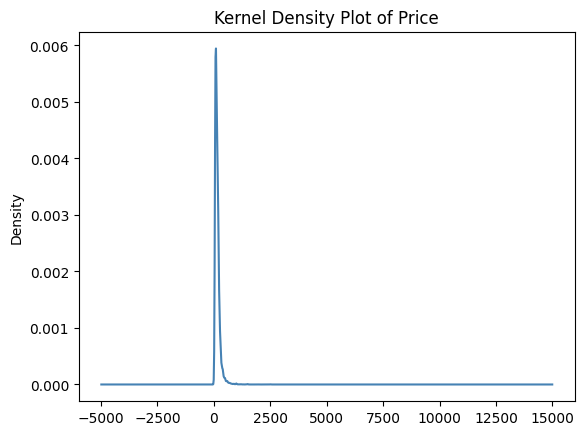

In [ ]:
# price has enormous outliers
# lets standardize it
house_raw["Price"].plot.kde(color='steelblue')
plt.title('Kernel Density Plot of Price')

Text(0.5, 1.0, 'Kernel Density Plot of Scores')

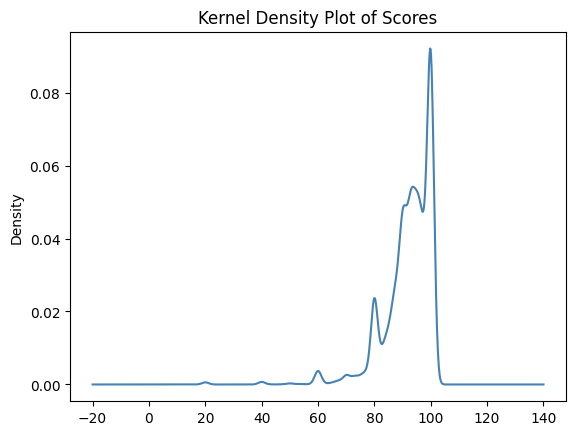

In [28]:
# rating has enormous outliers
# lets standardize it
house_raw["Review Scores Rating"].plot.kde(color='steelblue')
plt.title('Kernel Density Plot of Scores')

In [ ]:
# this will scale both columns
scaled_cols = ["Price" , "Review Scores Rating" ]
scalar = StandardScaler()

house_raw[scaled_cols] = scalar.fit_transform(house_raw[scaled_cols])


1. Compute the average prices and scores by `Neighborhood `; which borough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighborhood `.
2. Regress price on `Neighborhood ` by creating the appropriate dummy/one-hot-encoded variables, without an intercept in the linear model. Compare the coefficients in the regression to the table from part 1. What pattern do you see? What are the coefficients in a regression of a continuous variable on one categorical variable?
3. Repeat part 2, but leave an intercept in the linear model. How do you have to handle the creation of the dummies differently? What is the intercept? Interpret the coefficients. How can I get the coefficients in part 2 from these new coefficients?
4. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighborhood `. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
5. Run a regression of `Price` on `Review Scores Rating` and `Neighborhood ` and `Property Type`. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
6. What does the coefficient on `Review Scores Rating` mean if it changes from part 4 to 5? Hint: Think about how multiple linear regression works.
7. (Optional) We've included `Neighborhood ` and `Property Type` separately in the model. How do you interact them, so you can have "A bedroom in Queens" or "A townhouse in Manhattan". Split the sample 80/20 into a training and a test set and run a regression including that kind of "property type X neighborhood" dummy, plus `Review Scores Rating`. How does the slope coefficient for `Review Scores Rating`, the $R^2$, and the RMSE change? Do they increase significantly compares to part 5? Are the coefficients in this regression just the sum of the coefficients for `Neighbourhood ` and `Property Type` from 5? What is the most expensive kind of property you can rent?